# Training and fine-tuning of ResNet models on Oxford Pets dataset

This notebook demonstrates how to train and fine-tune ResNet models on the Oxford Pets dataset using Pytorch. For the training process, we choose to train from scratch the ResNet-18 and ResNet-50 models on the already mentioned dataset. On the other hand, we will fine-tune the both models on the same dataset, but they will be loaded with pre-trained weights from ImageNet.



In [1]:
import torch
import torchvision
from torch import nn
from torchvision import models
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
sys.path.append('src')
import dataset
import train

# 1. Download Dataset Oxford Pets

Use the following command to download the Oxford Pets dataset. The dataset will be downloaded in the `data/oxford_pets` directory.



In [ ]:
from torchvision.datasets.utils import download_and_extract_archive

def download(root):
    url_images = "https://thor.robots.ox.ac.uk/~vgg/data/pets/images.tar.gz"
    url_targets = "https://thor.robots.ox.ac.uk/~vgg/data/pets/annotations.tar.gz"
    download_and_extract_archive(url_images, root, remove_finished=False)
    download_and_extract_archive(url_targets, root, remove_finished=False)


download('./data/oxford_pets')

Using downloaded and verified file: ./data/oxford_pets/images.tar.gz
Extracting ./data/oxford_pets/images.tar.gz to ./data/oxford_pets
Using downloaded and verified file: ./data/oxford_pets/annotations.tar.gz
Extracting ./data/oxford_pets/annotations.tar.gz to ./data/oxford_pets


# 2. Train ResNet models from scratch

In this section, we'll train the both models from scratch on the Oxford Pets Dataset. The training process will be done using the `train.py` script, which is designed to handle the training of various models.

We save two checkpoints for each model: one at the end of each epoch and another of the best model based on the validation accuracy. 

## 2.1 Train ResNet-18

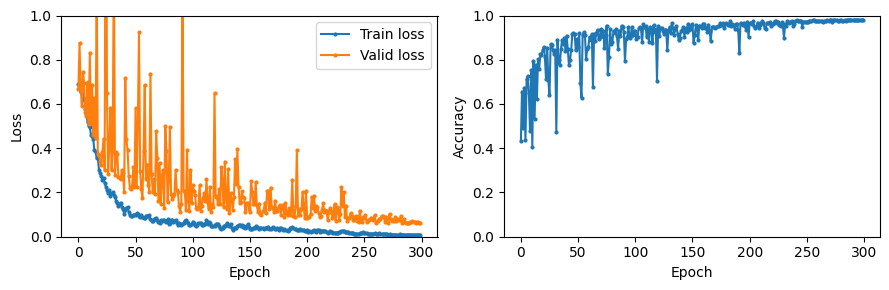

In [ ]:
params_resnet18 = {
    "bs": 256,
    "num_epochs": 300,
    "lr": 1e-2, 
    "weight_decay": 1e-2,
    "resize_size": 224,
    "seed": 0
}

model_resnet18 = models.resnet18(weights=None) # Use weights=None to initialize from scratch
model_resnet18.fc = nn.Linear(model_resnet18.fc.in_features, 2) # Change output layer for binary classification

ds_train, ds_valid, logger = train.train(
    model_resnet18, 
    checkpoint_path="checkpoints/resnet18_scratch",
    dataset_path="./data/oxford_pets",
    **params_resnet18, 
    
)


## 2.1 Train ResNet-50



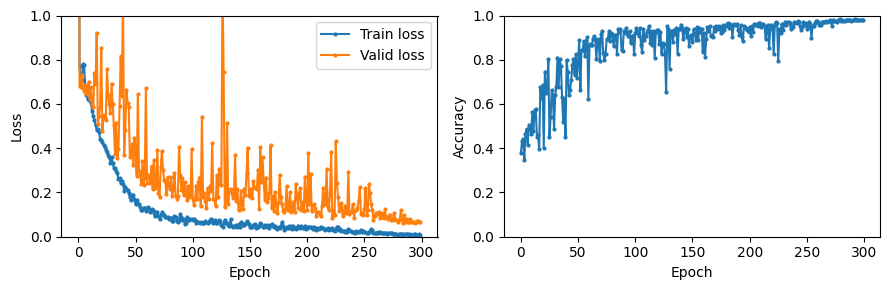

In [ ]:
params_resnet50 = {
    "bs": 256,  
    "num_epochs": 300,
    "lr": 1e-2,
    "weight_decay": 1e-2,
    "resize_size": 224,
    "seed": 0
}

model_resnet50 = models.resnet50(weights=None)
model_resnet50.fc = nn.Linear(model_resnet50.fc.in_features, 2)

ds_train, ds_valid, logger = train.train(
    model_resnet50, 
    checkpoint_path="checkpoints/resnet50_scratch",
    dataset_path="./data/oxford_pets",
    **params_resnet50, 

)

# 3 Tine-tune pre-trained ResNet models on Oxford Pets

In order to increase the performance of the models to the domain of the Oxford Pets dataset, we will leverage already pre-trained representation from ImageNet. The pre-trained weights will be loaded into the ResNet-18 and ResNet-50 models, and we will fine-tune them on the Oxford Pets dataset.

In this experiment, we will fine-tune all layers of the models.

## 3.1 Fine-tune ResNet-18

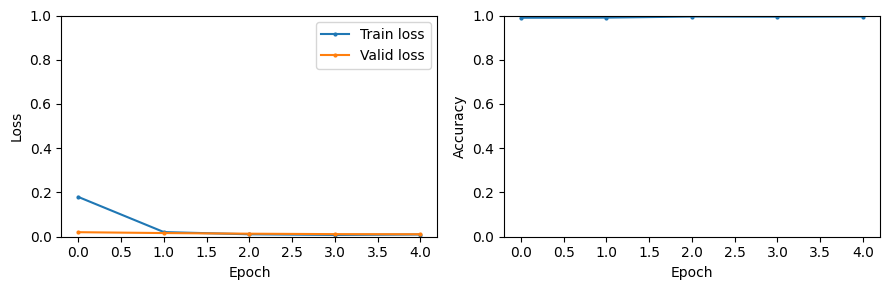

In [3]:
from torchvision.models import ResNet18_Weights

params_resnet18_tl = {
    "bs": 256,
    "num_epochs": 5,
    "lr": 1e-2, 
    "weight_decay": 1e-3,
    "resize_size": 224,
    "seed": 0
}

model_resnet18_tl = models.resnet18(weights=ResNet18_Weights.DEFAULT)
model_resnet18_tl.fc = nn.Linear(model_resnet18_tl.fc.in_features, 2) #  

ds_train, ds_valid, logger = train.train(
    model_resnet18_tl,
    checkpoint_path="checkpoints/resnet18_finetuned_on_oxford_pets",
    dataset_path="./data/oxford_pets",
    **params_resnet18_tl
    
)


## 3.2 Fine-tune ResNet-50

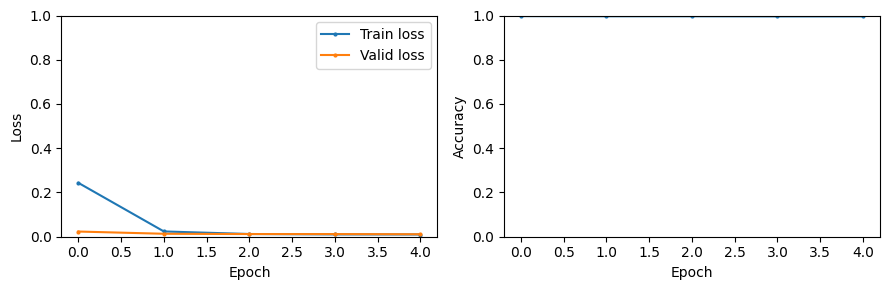

In [4]:
from torchvision.models import ResNet50_Weights

params_resnet50_tl = {
    "bs": 256,
    "num_epochs": 5,
    "lr": 1e-2, 
    "weight_decay": 1e-3,
    "resize_size": 224,
    "seed": 0
}

model_resnet50_tl = models.resnet50(weights=ResNet50_Weights.DEFAULT)
model_resnet50_tl.fc = nn.Linear(model_resnet50_tl.fc.in_features, 2)

ds_train, ds_valid, logger = train.train(
    model_resnet50_tl, 
    checkpoint_path="checkpoints/resnet50_finetuned_on_oxford_pets",
    dataset_path="./data/oxford_pets",
    **params_resnet50_tl
)
